In [122]:
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from scipy.stats import norm

import cv2

In [179]:
def plot_real_line(ax):
    xs = np.linspace(-5, 5, 500)

    # N(mu, sigma2)
    f1_xs = norm.pdf(xs, loc = -2.0, scale = 1.0)
    f2_xs = norm.pdf(xs, loc = -1.0, scale = 2.0)
    f3_xs = norm.pdf(xs, loc = 2.0, scale = 0.7)
    
    # Laplace(0, b)
    b = 0.5
    f4_xs = 1/(2*b) * np.exp(-np.abs(xs - 0) / b)
    
    # Gumbel(mu, beta)
    mu = -1
    beta = 0.5
    zs = (xs - mu) / beta
    f5_xs = 1/beta * np.exp(-(zs + np.exp(-zs)) )
    
    ax.plot(xs, f1_xs, label = "Normal(-2, 1)")
    ax.plot(xs, f2_xs, label = "Normal(-1, 2)")
    ax.plot(xs, f3_xs, label = "Normal(2, 0.7)")
    ax.plot(xs, f4_xs, label = "Laplace(0, 0.5)")
    ax.plot(xs, f5_xs, label = "Gumbel(0, 0.5)")
    
    ax.set_xlabel("X")
    ax.set_title(r"Densidades reais $\mathbb{R}$", fontsize = 20)
    ax.legend(loc = "upper right", fontsize = 16)

In [180]:
def plot_positive_line(ax):
    xs = np.linspace(0.001, 10, 500)

    # Exp(scale)
    f1_xs = 1/2 * np.exp(-xs/2)
    f2_xs = 1/4 * np.exp(-xs/4)
    
    # Weibull(k, lam)
    def dweibull(x, k, lam):
        return k / lam**k * x**(k-1) *np.exp(-(x / lam)**k)
    f3_xs = dweibull(xs, 3.0, 1.5)
    f4_xs = dweibull(xs, 5.0, 5.0)
    
    # Log-normal(mu, sigma)
    mu = 0
    sigma = 0.5
    f5_xs = 1/(xs * sigma * np.sqrt(2*np.pi)) * np.exp(-(np.log(xs) - mu)**2 / (2*sigma**2))
    
    ax.plot(xs, f1_xs, label = "Exp(2)")
    ax.plot(xs, f2_xs, label = "Exp(4)")
    ax.plot(xs, f3_xs, label = "Weibull(5, 1)")
    ax.plot(xs, f4_xs, label = "Weibull(5, 5)")
    ax.plot(xs, f5_xs, label = "Log-normal(0, 0.5)")
    
    ax.set_xlabel("X")
    ax.set_title(r"Densidades positivas $\mathbb{R}_+$", fontsize = 20)
    ax.legend(loc = "upper right", fontsize = 16)

In [181]:
from scipy.special import loggamma

def plot_limited_line(ax):
    xs = np.linspace(0.001, 1, 500)

    # Beta(a, b)
    def dbeta(x, a, b):
        B_ab = np.exp( loggamma(a) + loggamma(b) - loggamma(a + b) )
        return x**(a-1) * (1-x)**(b-1) / B_ab
    f1_xs = dbeta(xs, 3.0, 1.0)
    f2_xs = dbeta(xs, 4.0, 4.0)
    f3_xs = dbeta(xs, 2.0, 12.0)
    
    # Kumaraswamy(a, b)
    def dkumaraswamy(x, a, b):
        return a*b*x**(a-1)*(1-x**a)**(b-1)

    f4_xs = dkumaraswamy(xs, 2.0, 5.0)
    f5_xs = dkumaraswamy(xs, 7.0, 10.0)
    
    ax.plot(xs, f1_xs, label = "Beta(3, 1)")
    ax.plot(xs, f2_xs, label = "Beta(4, 4)")
    ax.plot(xs, f3_xs, label = "Beta(2, 12)")
    ax.plot(xs, f4_xs, label = "Kumaraswamy(2, 5)")
    ax.plot(xs, f5_xs, label = "Kumaraswamy(7, 10)")
    
    ax.set_xlabel("X")
    ax.set_title(r"Densidades Limitadas $(0,1)$", fontsize = 20)
    ax.legend(loc = "upper right", fontsize = 16)

In [182]:
from scipy.special import loggamma

def plot_discrete(ax):
    xs = np.arange(16)

    # Bernouli(p)
    xs1 = np.arange(2)
    f1_xs = np.array([0.3, 0.7])
    
    # Poisson(lam)
    def dpoisson(x, lam):
        return np.exp( -lam + x * np.log(lam) - loggamma(x) )
    xs2 = np.arange(21)
    f2_xs = dpoisson(xs2, 4)
    f3_xs = dpoisson(xs2, 8)

    sns.barplot(x = xs1, y = f1_xs, label = "Bernoulli(0.7)", ax = ax, width = 0.5, alpha = 0.5)
    sns.barplot(x = xs2, y = f2_xs, label = "Poisson(4)", ax = ax, width = 0.5, alpha = 0.5)
    sns.barplot(x = xs2, y = f3_xs, label = "Poisson(8)", ax = ax, width = 0.5, alpha = 0.5)
    
    ax.set_xlabel("X")
    ax.set_title(r"Probabilidades discretas $\mathbb{N}$", fontsize = 20)
    ax.legend(loc = "upper right", fontsize = 16)

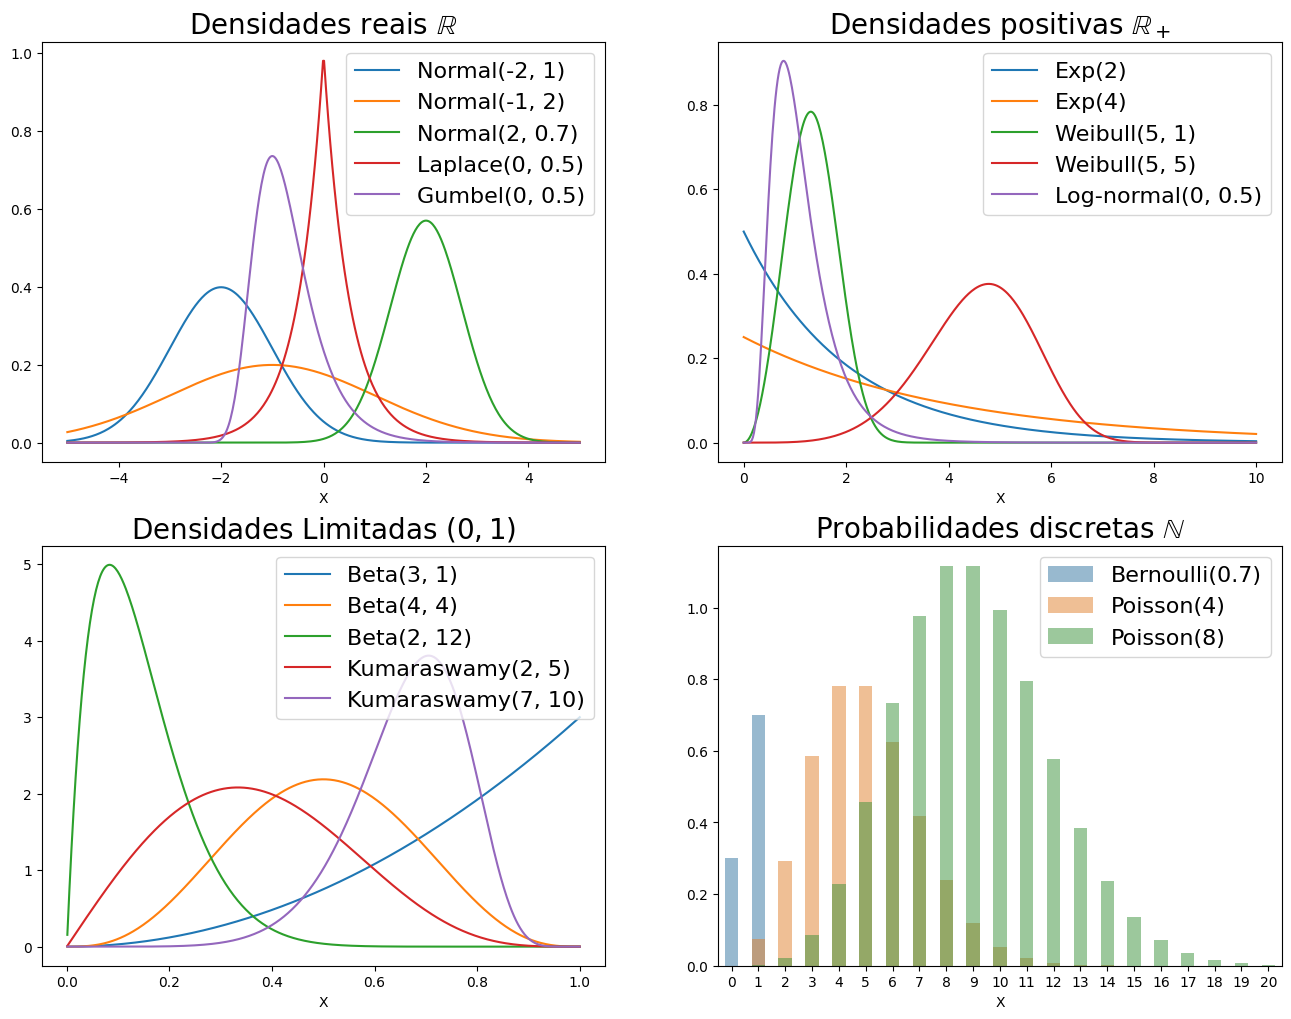

In [183]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (16,12))

plot_real_line(ax[0,0])
plot_positive_line(ax[0,1])
plot_limited_line(ax[1,0])
plot_discrete(ax[1,1])